<a href="https://colab.research.google.com/github/project-ida/arpa-e-experiments/blob/main/templates/eds-sample-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<a href="https://nbviewer.org/github/project-ida/arpa-e-experiments/blob/main/templates/eds-sample-analysis.ipynb" target="_parent"><img src="https://nbviewer.org/static/img/nav_logo.svg" alt="Open In nbviewer" width="100"/></a>

# EDS Analysis template

This notebook provides a quick, end-to-end demo for ROI-based EDS analysis:
it pulls saved regions from the Surface Viewer API, builds a table of selected cells, loads the corresponding spectra, aggregates them, and runs a simple first-pass peak analysis.

## How to use

1. Add the `api_url` (get the link from a surface viewer selection grid)
name.
2. Run cells top-to-bottom.
3. Use the aggregate plot and peak table as a rapid “first look” before moving to the full testbed.


In [1]:
# Set up the GitHub repo in Colab so the shared helper modules can be imported.

!pip install colocal -q
import colocal
root, branch, cwd = colocal.setup("https://github.com/project-ida/arpa-e-experiments")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.8 MB/s eta 0:00:00
[Colab] Repo: arpa-e-experiments | Branch: None
[Colab] Repo root added to sys.path
[Colab] Working directory set to: .


In [2]:
# Import Python libraries, URL helpers, and reusable Surface Viewer analysis modules.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import urlparse, parse_qs, quote_plus

from libs.surface_viewer.io import (
    get_roi_name_from_api_url,
    load_roi_api,
    add_json_urls,
    load_all_cells_from_selection_grid,
    build_spectrum_index,
    attach_spectra,
)

from libs.surface_viewer.spectra import (
    stack_spectra_trim,
    band_sum,
    summarize_band_values,
    resolve_band_to_channels,
    band_label_text,
)

from libs.surface_viewer.calibration import (
    maybe_get_calibration,
    channel_to_keV,
    make_energy_axis,
)

from libs.surface_viewer.peaks import (
    baseline_als,
    preprocess,
    detect_peaks,
    identify_elements,
)

from libs.surface_viewer.plotting import (
    add_energy_top_axis,
    plot_cumulative,
    plot_overlay,
    plot_with_peaks,
    plot_identified_elements_confident,
    plot_overlaid_cell_spectra,
)

from libs.surface_viewer.overlays import (
    get_api_auth,
    create_overlay,
    delete_overlay,
)

In [3]:
# Define ROI URLs and the main analysis parameters for loading, calibration, and peak finding.

ROI_API_URLS = [
    "https://nucleonics.mit.edu/surface-viewer/api/rois.php?dataset=JPB1_Pd-TF-11_EDS_post%20(20250825_sample%209%20(eds))&name=sample-corner",
    "https://nucleonics.mit.edu/surface-viewer/api/rois.php?dataset=JPB1_Pd-TF-11_EDS_post%20(20250825_sample%209%20(eds))&name=margin",
]

# General display / loading behavior
LOAD_ALL_CELLS = True
SHOW_ENERGY_TOP_AXIS = True
ALLOW_DEFAULT_CALIBRATION = True

# Peak-analysis knobs
PEAK_MAX_PEAKS = 6
PEAK_TOP_N_LABELS = 6
PEAK_BEAM_KEV = 15.0
PEAK_FWHM_MN_EV = 67.8


## 1. Load ROI selections and, optionally, the full mosaic cell grid


In [4]:
# Load ROI selections and, if requested, enumerate all cells from overlays/selection-grid.json.

roi_frames = {}
all_cells_df = pd.DataFrame()

for api_url in ROI_API_URLS:
    roi_name = get_roi_name_from_api_url(api_url)
    df = load_roi_api(api_url)
    df = add_json_urls(df, api_url)
    df["roi_name"] = roi_name
    roi_frames[roi_name] = df

    print(f"{roi_name}: {len(df)} selected cells")
    if not df.empty:
        display(df.head())

if LOAD_ALL_CELLS:
    all_cells_df = load_all_cells_from_selection_grid(ROI_API_URLS[0])
    print(f"all-cells: {len(all_cells_df)} cells enumerated from overlays/selection-grid.json")
    if not all_cells_df.empty:
        display(all_cells_df.head())


sample-corner: 80 selected cells


,col,row,srcJson,basename,foldername,json_url,roi_name
0,0,2,aggregated-spectra/Project 1 9 Area 1 Site 8 M...,Project 1 9 Area 1 Site 8 Map Data 7,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner
1,1,2,aggregated-spectra/Project 1 9 Area 1 Site 8 M...,Project 1 9 Area 1 Site 8 Map Data 7,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner
2,1,0,aggregated-spectra/Project 1 9 Area 1 Site 26 ...,Project 1 9 Area 1 Site 26 Map Data 25,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner
3,1,1,aggregated-spectra/Project 1 9 Area 1 Site 26 ...,Project 1 9 Area 1 Site 26 Map Data 25,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner
4,1,2,aggregated-spectra/Project 1 9 Area 1 Site 26 ...,Project 1 9 Area 1 Site 26 Map Data 25,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,sample-corner


margin: 104 selected cells


,col,row,srcJson,basename,foldername,json_url,roi_name
0,0,0,aggregated-spectra/Project 1 9 Area 1 Site 7 M...,Project 1 9 Area 1 Site 7 Map Data 6,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin
1,0,1,aggregated-spectra/Project 1 9 Area 1 Site 7 M...,Project 1 9 Area 1 Site 7 Map Data 6,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin
2,1,1,aggregated-spectra/Project 1 9 Area 1 Site 7 M...,Project 1 9 Area 1 Site 7 Map Data 6,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin
3,1,0,aggregated-spectra/Project 1 9 Area 1 Site 7 M...,Project 1 9 Area 1 Site 7 Map Data 6,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin
4,2,1,aggregated-spectra/Project 1 9 Area 1 Site 7 M...,Project 1 9 Area 1 Site 7 Map Data 6,aggregated-spectra,https://nucleonics.mit.edu/surface-viewer/data...,margin


all-cells: 3780 cells enumerated from overlays/selection-grid.json


,row,col,srcJson,basename,label,x,y,width,height,json_url
0,0,0,aggregated-spectra/Project 1 9 Area 1 Site 10 ...,Project 1 9 Area 1 Site 10 Map Data 9,"Project 1 9 Area 1 Site 10 Map Data 9 · r0, c0",8434.808731,393.077850,187.395392,140.546544,https://nucleonics.mit.edu/surface-viewer/data...
1,0,1,aggregated-spectra/Project 1 9 Area 1 Site 10 ...,Project 1 9 Area 1 Site 10 Map Data 9,"Project 1 9 Area 1 Site 10 Map Data 9 · r0, c1",8622.204123,393.077850,187.395392,140.546544,https://nucleonics.mit.edu/surface-viewer/data...
2,0,2,aggregated-spectra/Project 1 9 Area 1 Site 10 ...,Project 1 9 Area 1 Site 10 Map Data 9,"Project 1 9 Area 1 Site 10 Map Data 9 · r0, c2",8809.599515,393.077850,187.395392,140.546544,https://nucleonics.mit.edu/surface-viewer/data...
3,1,0,aggregated-spectra/Project 1 9 Area 1 Site 10 ...,Project 1 9 Area 1 Site 10 Map Data 9,"Project 1 9 Area 1 Site 10 Map Data 9 · r1, c0",8434.808731,533.624394,187.395392,140.546544,https://nucleonics.mit.edu/surface-viewer/data...
4,1,1,aggregated-spectra/Project 1 9 Area 1 Site 10 ...,Project 1 9 Area 1 Site 10 Map Data 9,"Project 1 9 Area 1 Site 10 Map Data 9 · r1, c1",8622.204123,533.624394,187.395392,140.546544,https://nucleonics.mit.edu/surface-viewer/data...


In [5]:
# Collect the unique spectrum JSON URLs needed across ROI selections and the all-cells grid.

roi_urls = sorted(set(
    url
    for df in roi_frames.values()
    for url in df["json_url"].dropna().unique().tolist()
))

all_cell_urls = []
if LOAD_ALL_CELLS and not all_cells_df.empty:
    all_cell_urls = sorted(all_cells_df["json_url"].dropna().unique().tolist())

all_urls = sorted(set(roi_urls) | set(all_cell_urls))

print(f"Will download {len(all_urls)} unique JSON file(s) across ROI sets and the all-cells grid")
index = build_spectrum_index(all_urls, progress=True)


Will download 420 unique JSON file(s) across ROI sets and the all-cells grid


In [6]:
# Attach spectra to the ROI tables and the optional all-cells table.

for roi_name, df in roi_frames.items():
    roi_frames[roi_name] = attach_spectra(df, index, progress=True)

    ok = roi_frames[roi_name]["spectrum"].notna().sum()
    print(f"{roi_name}: spectra attached for {ok} / {len(roi_frames[roi_name])} selections")

if LOAD_ALL_CELLS and not all_cells_df.empty:
    all_cells_df = attach_spectra(all_cells_df, index, progress=True)
    ok_all = all_cells_df["spectrum"].notna().sum()
    print(f"all-cells: spectra attached for {ok_all} / {len(all_cells_df)} cells")


Indexing spectra: 100%|██████████| 80/80 [00:00<00:00, 18200.49it/s]


sample-corner: spectra attached for 80 / 80 selections


Indexing spectra: 100%|██████████| 104/104 [00:00<00:00, 17910.39it/s]


margin: spectra attached for 104 / 104 selections


Indexing spectra: 100%|██████████| 3780/3780 [00:00<00:00, 51404.62it/s]

all-cells: spectra attached for 3780 / 3780 cells


In [7]:
# Print quick summaries of the selected ROI cells by basename and source spectrum file.

for roi_name, df in roi_frames.items():
    print(f"\n=== {roi_name} ===")
    if df.empty:
        print("No selections")
        continue

    print(f"Selected cells: {len(df)}")
    if "basename" in df.columns:
        print(f"Unique basenames: {df['basename'].nunique()}")
    if "srcJson" in df.columns:
        print(f"Unique spectrum JSON files: {df['srcJson'].nunique()}")

    display(df.groupby("basename", dropna=False).size().sort_values(ascending=False).to_frame("n_selected").head(20))

if LOAD_ALL_CELLS and not all_cells_df.empty:
    print("\n=== all-cells ===")
    print(f"Cells in full mosaic: {len(all_cells_df)}")
    if "basename" in all_cells_df.columns:
        print(f"Unique basenames: {all_cells_df['basename'].nunique()}")
    if "srcJson" in all_cells_df.columns:
        print(f"Unique spectrum JSON files: {all_cells_df['srcJson'].nunique()}")



=== sample-corner ===
Selected cells: 80
Unique basenames: 12
Unique spectrum JSON files: 12


,n_selected
basename,
Project 1 9 Area 1 Site 28 Map Data 27,9
Project 1 9 Area 1 Site 27 Map Data 26,9
Project 1 9 Area 1 Site 46 Map Data 45,9
Project 1 9 Area 1 Site 45 Map Data 44,9
Project 1 9 Area 1 Site 64 Map Data 63,9
Project 1 9 Area 1 Site 63 Map Data 62,9
Project 1 9 Area 1 Site 62 Map Data 61,6
Project 1 9 Area 1 Site 26 Map Data 25,6
Project 1 9 Area 1 Site 44 Map Data 43,6



=== margin ===
Selected cells: 104
Unique basenames: 29
Unique spectrum JSON files: 29


,n_selected
basename,
Project 1 9 Area 1 Site 7 Map Data 6,7
Project 1 9 Area 1 Site 4 Map Data 3,6
Project 1 9 Area 1 Site 6 Map Data 5,6
Project 1 9 Area 1 Site 3 Map Data 2,6
Project 1 9 Area 1 Site 5 Map Data 4,6
Project 1 9 Area 1 Site 2 Map Data 1,4
Project 1 9 Area 1 Site 187 Map Data 186,3
Project 1 9 Area 1 Site 223 Map Data 222,3
Project 1 9 Area 1 Site 205 Map Data 204,3



=== all-cells ===
Cells in full mosaic: 3780
Unique basenames: 420
Unique spectrum JSON files: 420


*Step 2: Build aggregate spectra for all cells and each ROI region.*

## 2. Build aggregate spectra for all cells and for each ROI region


In [8]:
# Build aggregate stacks, cumulative spectra, and mean spectra for each analysis group.

need_calibration = True
cal = maybe_get_calibration(
    ROI_API_URLS,
    need_calibration=need_calibration,
    allow_defaults=ALLOW_DEFAULT_CALIBRATION,
)

roi_results = {}
for api_url in ROI_API_URLS:
    roi_name = get_roi_name_from_api_url(api_url)
    df = roi_frames[roi_name]
    df_ok = df[df["spectrum"].notna()].copy()

    if df_ok.empty:
        print(f"{roi_name}: no spectra available")
        continue

    stack, x = stack_spectra_trim(df_ok["spectrum"])
    roi_results[roi_name] = {
        "label": roi_name,
        "api_url": api_url,
        "df": df_ok,
        "stack": stack,
        "x": x,
        "cumulative": stack.sum(axis=0),
        "mean_spectrum": stack.mean(axis=0),
    }
    print(f"{roi_name}: {stack.shape[0]} spectra, common length {stack.shape[1]}")

all_cells_result = None
if LOAD_ALL_CELLS and not all_cells_df.empty:
    df_all_ok = all_cells_df[all_cells_df["spectrum"].notna()].copy()
    if not df_all_ok.empty:
        stack_all, x_all = stack_spectra_trim(df_all_ok["spectrum"])
        all_cells_result = {
            "label": "all-cells",
            "api_url": ROI_API_URLS[0],
            "df": df_all_ok,
            "stack": stack_all,
            "x": x_all,
            "cumulative": stack_all.sum(axis=0),
            "mean_spectrum": stack_all.mean(axis=0),
        }
        print(f"all-cells: {stack_all.shape[0]} spectra, common length {stack_all.shape[1]}")

aggregate_results = {}
if all_cells_result is not None:
    aggregate_results["all-cells"] = all_cells_result
for api_url in ROI_API_URLS:
    roi_name = get_roi_name_from_api_url(api_url)
    if roi_name in roi_results:
        aggregate_results[roi_name] = roi_results[roi_name]


sample-corner: 80 spectra, common length 2048
margin: 104 spectra, common length 2048
all-cells: 3780 spectra, common length 2048


In [9]:
# Report which energy calibration was found and whether config values or defaults are being used.

if cal is not None:
    source_text = "config.txt" if cal.get("from_config") else "defaults"
    print(f"Energy calibration source: {source_text}")
    print("Calibration:", cal)
else:
    print("No energy calibration available; top energy axis will be omitted.")


Energy calibration source: config.txt
Calibration: {'dataset_base': 'https://nucleonics.mit.edu/surface-viewer/data/JPB1_Pd-TF-11_EDS_post%20%2820250825_sample%209%20%28eds%29%29/', 'eV_per_ch': 9.998198509216309, 'start_eV': -197.4116973876953, 'n_channels': 2048, 'raw_cfg': {'um_per_px': '0.6100110411643982', 'shift_x_px': '509.75', 'shift_y_px': '639.75', 'rotation': '0+0.25-0.05', 'scale': '1', 'total_width_px': '16771', 'total_height_px': '16689', 'eds_ev_per_ch': '9.998198509216309', 'eds_start_ev': '-197.4116973876953', 'eds_n_channels': '2048'}, 'from_config': True}


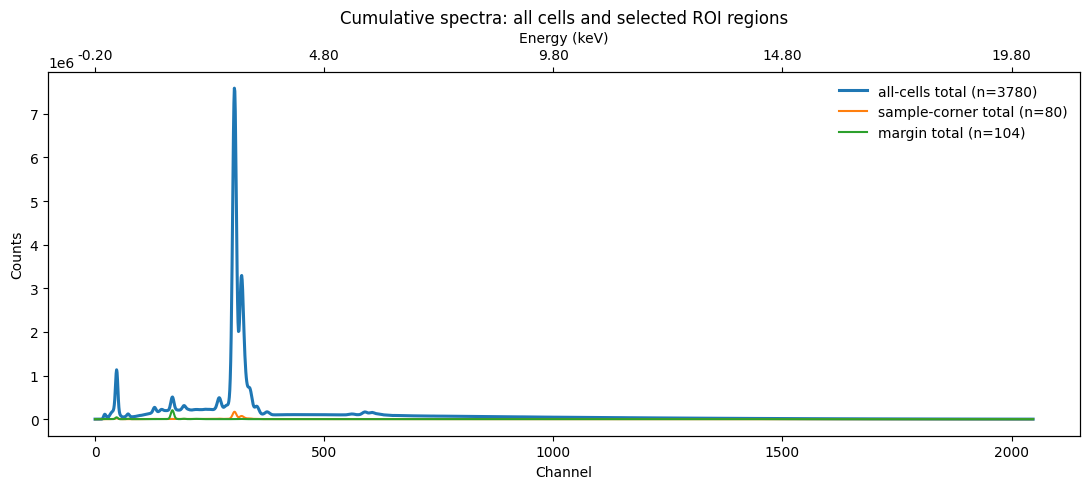

In [10]:
# Plot cumulative spectra for all cells and ROI regions on a common axis.

fig, ax = plt.subplots(figsize=(11, 5))

for name, res in aggregate_results.items():
    y = res["cumulative"]
    x_plot = np.arange(len(y))
    lw = 2.2 if name == "all-cells" else 1.5
    ax.plot(x_plot, y, label=f"{name} total (n={res['stack'].shape[0]})", lw=lw)

ax.set_xlabel("Channel")
ax.set_ylabel("Counts")
ax.set_title("Cumulative spectra: all cells and selected ROI regions")

if SHOW_ENERGY_TOP_AXIS and cal is not None:
    max_len = max(len(res["cumulative"]) for res in aggregate_results.values())
    add_energy_top_axis(ax, cal=cal, n=max_len)

ax.legend(frameon=False)
fig.tight_layout()
plt.show()


*Step 2b: Run basic conditioning and first-pass element identification on the aggregate spectra.*

### Basic conditioning and peak identification on the aggregate spectra



=== all-cells: cumulative spectrum ===


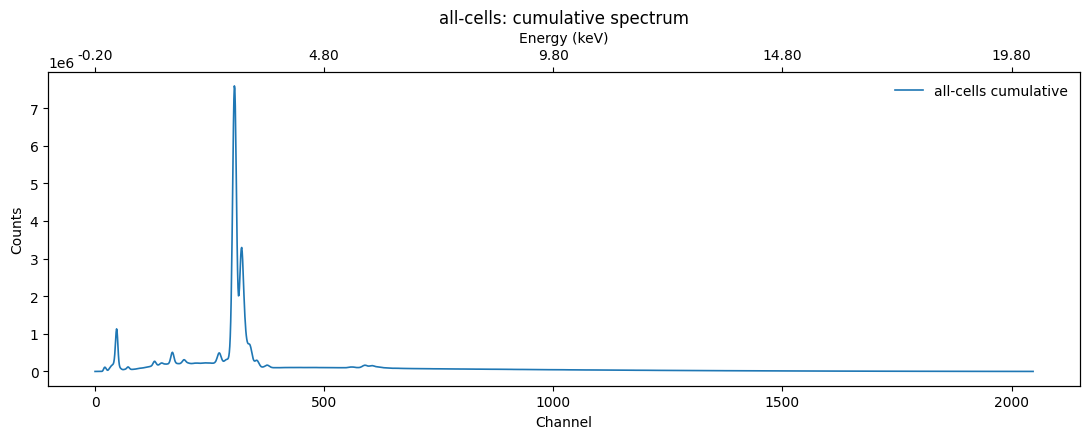

/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


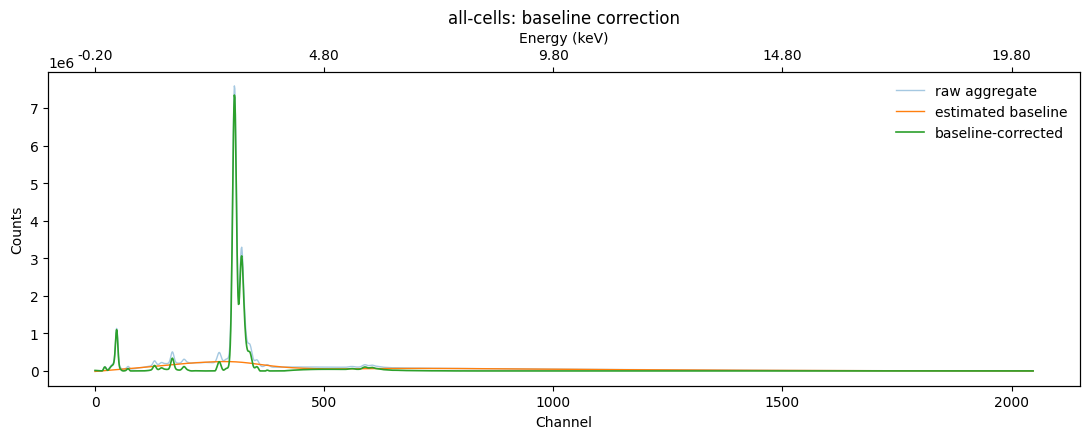

Noise estimate: 23.589866726053643
min_prom: 141.53920035632186
min_height: 70.76960017816093


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,x,idx,height,prominence,fwhm,area
0,47.0,47,7.425676e+05,7.332477e+05,12.210704,7.780129e+06
1,130.0,130,1.110253e+05,8.036952e+04,11.351346,1.137199e+06
2,169.0,169,2.629219e+05,2.629219e+05,12.703911,2.885051e+06
3,271.0,271,2.034226e+05,2.034226e+05,12.083404,2.085206e+06
4,304.0,304,6.150169e+06,6.150169e+06,13.666765,6.873051e+07
5,321.0,321,2.557734e+06,3.135564e+05,4.754011,1.484904e+07


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,energy_keV,idx,height,prominence,area,fwhm,element,line,lib_energy_keV,delta_keV,label
0,0.272504,47,7.425676e+05,7.332477e+05,77787.270231,12.210704,C,Ka1,0.2770,0.004496,C Ka1
1,1.102354,130,1.110253e+05,8.036952e+04,11369.944513,11.351346,Na,Ka1,1.0403,-0.062054,Na Ka1
2,1.492284,169,2.629219e+05,2.629219e+05,28845.313368,12.703911,Al,Ka1,1.4865,-0.005784,Al Ka1
3,2.512100,271,2.034226e+05,2.034226e+05,20848.305157,12.083404,S,Kb1,2.4650,-0.047100,S Kb1
4,2.842041,304,6.150169e+06,6.150169e+06,687181.293448,13.666765,Pd,La1,2.8378,-0.004241,Pd La1
5,3.012010,321,2.557734e+06,3.135564e+05,148463.613411,4.754011,Pd,Lb1,2.9895,-0.022510,Pd Lb1


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


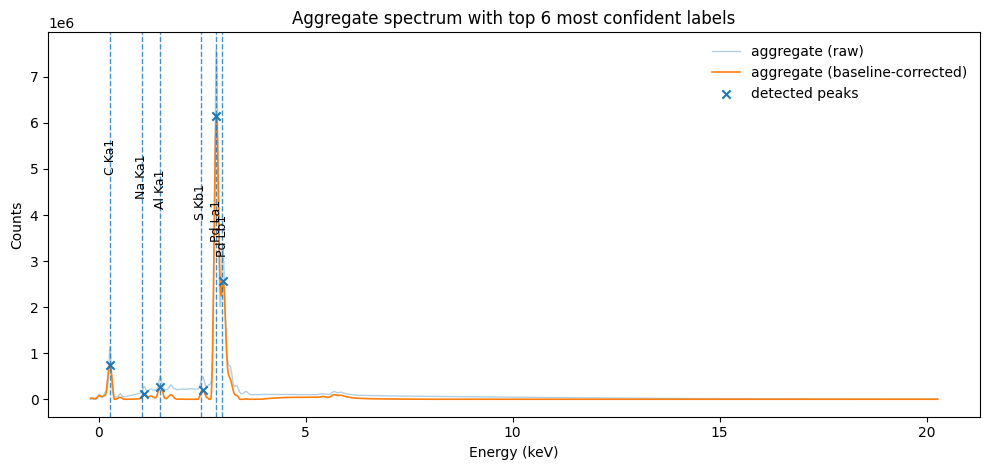


=== sample-corner: cumulative spectrum ===


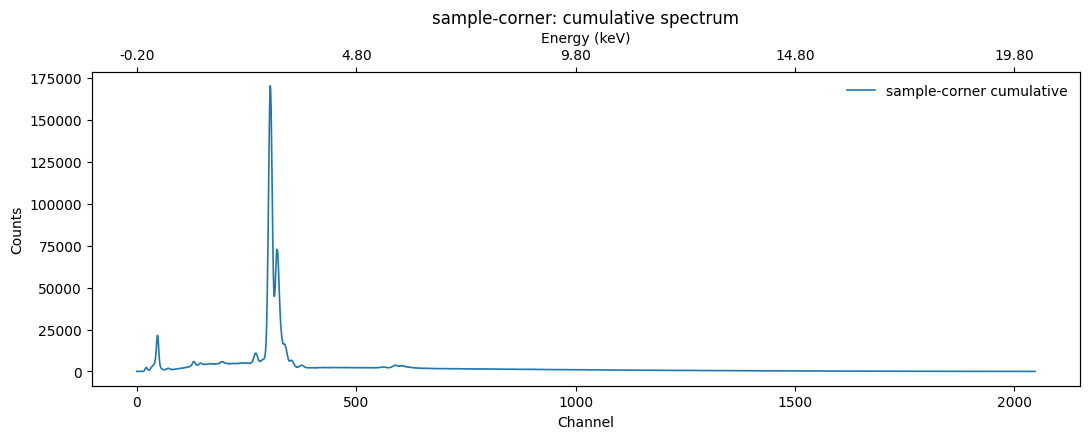

/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


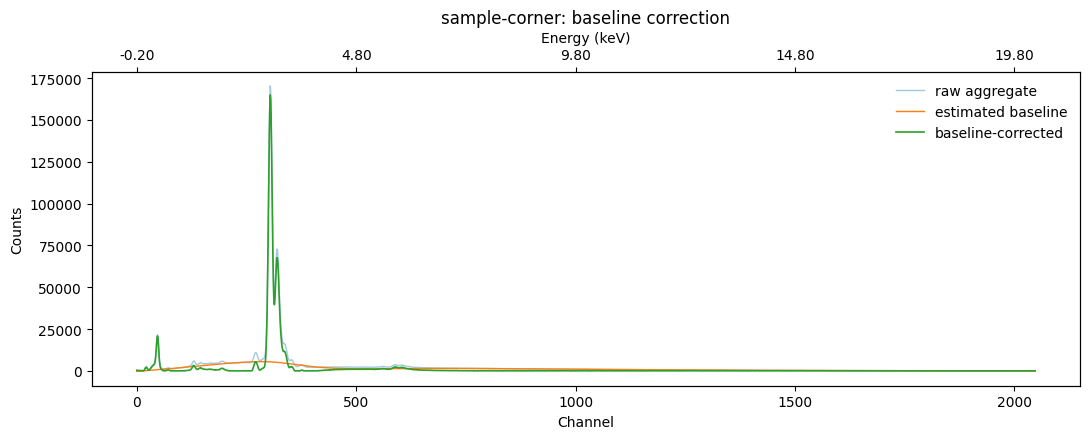

Noise estimate: 2.681224162455054
min_prom: 16.087344974730325
min_height: 8.043672487365162


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,x,idx,height,prominence,fwhm,area
0,47.0,47,14363.895275,14187.364328,12.390897,1.514104e+05
1,130.0,130,2486.398037,2486.398037,14.603607,2.945015e+04
2,271.0,271,4564.576287,4564.576287,12.086291,4.683006e+04
3,304.0,304,137646.674979,137646.674979,13.661622,1.538079e+06
4,320.0,320,57015.981905,6907.557175,4.753179,3.311649e+05
5,589.0,589,2182.707897,2182.707897,44.230517,7.720374e+04


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,energy_keV,idx,height,prominence,area,fwhm,element,line,lib_energy_keV,delta_keV,label
0,0.272504,47,14363.895275,14187.364328,1513.831030,12.390897,C,Ka1,0.2770,0.004496,C Ka1
1,1.102354,130,2486.398037,2486.398037,294.448486,14.603607,Na,Ka1,1.0403,-0.062054,Na Ka1
2,2.512100,271,4564.576287,4564.576287,468.216271,12.086291,S,Kb1,2.4650,-0.047100,S Kb1
3,2.842041,304,137646.674979,137646.674979,15378.023649,13.661622,Pd,La1,2.8378,-0.004241,Pd La1
4,3.002012,320,57015.981905,6907.557175,3311.052591,4.753179,Pd,Lb1,2.9895,-0.012512,Pd Lb1


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


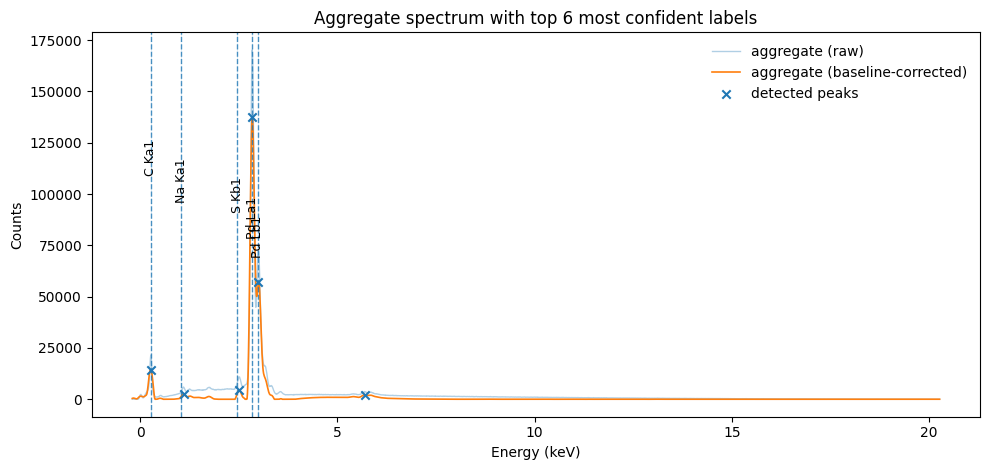


=== margin: cumulative spectrum ===


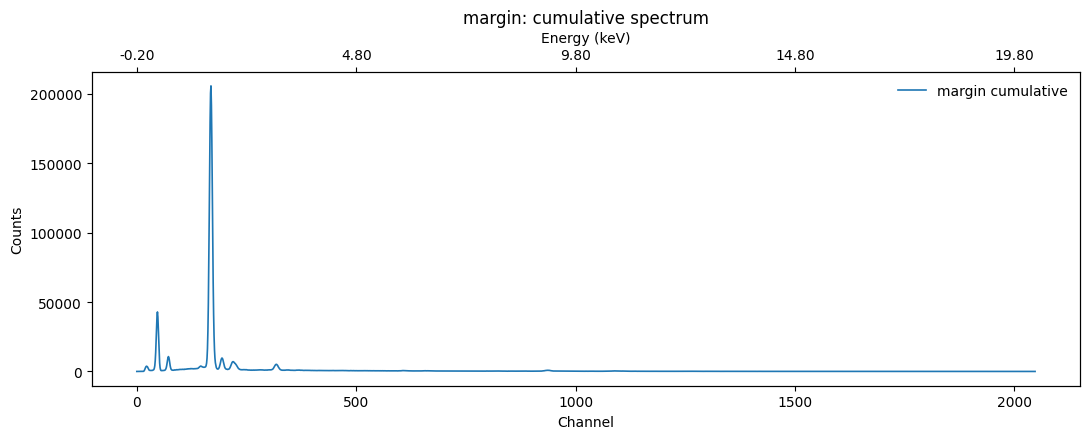

/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


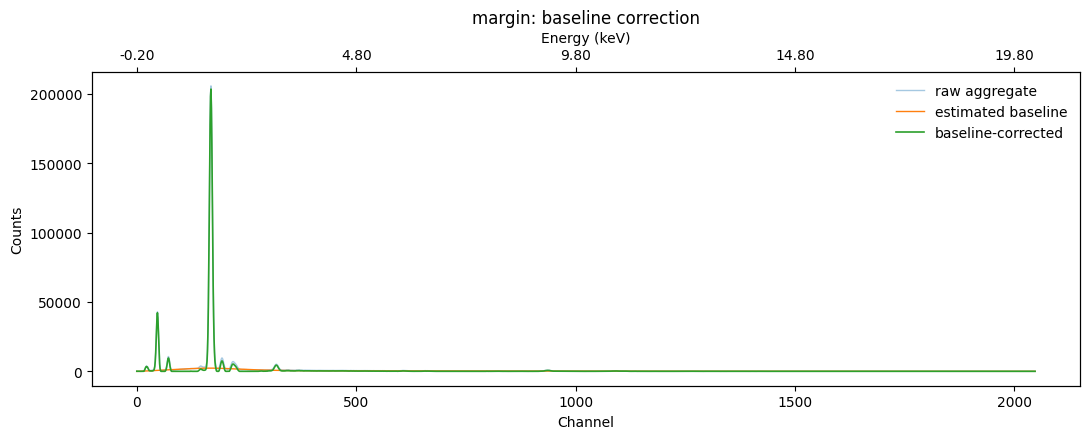

Noise estimate: 1.3833516814916247
min_prom: 8.300110088949747
min_height: 4.150055044474874


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,x,idx,height,prominence,fwhm,area
0,47.0,47,27070.643144,27070.643144,11.502825,2.636083e+05
1,72.0,72,7509.650426,7509.650426,12.325766,8.168720e+04
2,169.0,169,154801.932740,154801.932740,11.797615,1.581072e+06
3,194.0,194,7173.106643,7173.106643,12.294737,7.472994e+04
4,221.0,221,5970.237304,5378.623308,14.458315,7.321897e+04
5,318.0,318,3687.679571,3537.202506,12.602976,4.068373e+04


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


,energy_keV,idx,height,prominence,area,fwhm,element,line,lib_energy_keV,delta_keV,label
0,0.272504,47,27070.643144,27070.643144,2635.608041,11.502825,C,Ka1,0.2770,0.004496,C Ka1
1,0.522459,72,7509.650426,7509.650426,816.724885,12.325766,O,Ka1,0.5249,0.002441,O Ka1
2,1.492284,169,154801.932740,154801.932740,15807.872855,11.797615,Al,Ka1,1.4865,-0.005784,Al Ka1
3,1.742239,194,7173.106643,7173.106643,747.164732,12.294737,Si,Ka1,1.7398,-0.002439,Si Ka1
4,2.012190,221,5970.237304,5378.623308,732.057822,14.458315,P,Ka1,2.0105,-0.001690,P Ka1
5,2.982015,318,3687.679571,3537.202506,406.764046,12.602976,Ag,La1,2.9827,0.000685,Ag La1


/content/arpa-e-experiments/libs/surface_viewer/peaks.py:19: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w * y)


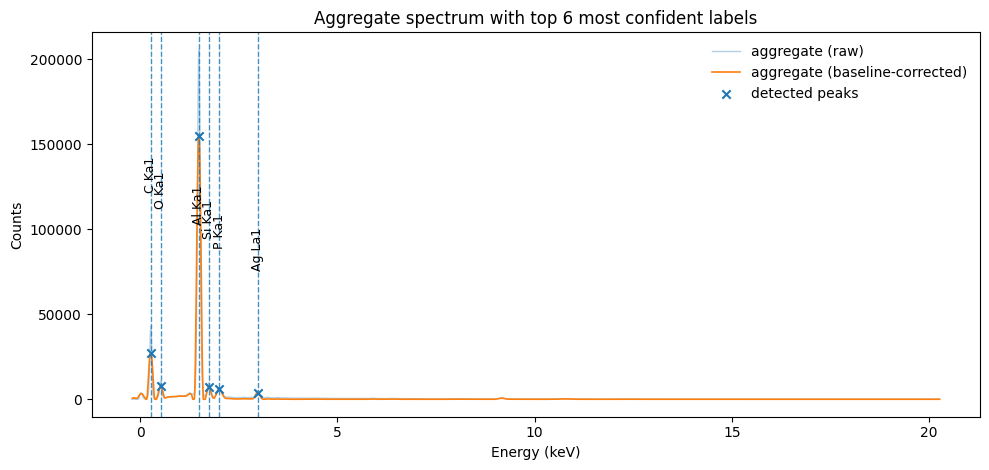

In [11]:
# Condition each aggregate spectrum, detect peaks, and print first-pass element assignments.

peak_summary = {}

for name, res in aggregate_results.items():
    print(f"\n=== {name}: cumulative spectrum ===")
    cum = np.asarray(res["cumulative"], dtype=float)
    x = np.arange(len(cum))

    # Plot raw cumulative spectrum with channel axis and optional energy top axis
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(x, cum, lw=1.2, label=f"{name} cumulative")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Counts")
    ax.set_title(f"{name}: cumulative spectrum")
    if SHOW_ENERGY_TOP_AXIS and cal is not None:
        add_energy_top_axis(ax, cal=cal, n=len(cum))
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    # Baseline/corrected view (same spirit as the demo notebook)
    baseline = baseline_als(cum)
    corrected = np.clip(cum - baseline, 0, None)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(x, cum, lw=1.0, alpha=0.4, label="raw aggregate")
    ax.plot(x, baseline, lw=1.0, label="estimated baseline")
    ax.plot(x, corrected, lw=1.2, label="baseline-corrected")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Counts")
    ax.set_title(f"{name}: baseline correction")
    if SHOW_ENERGY_TOP_AXIS and cal is not None:
        add_energy_top_axis(ax, cal=cal, n=len(cum))
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    # Peak detection table
    peaks_df, meta = detect_peaks(cum, x=x, max_peaks=PEAK_MAX_PEAKS)
    print("Noise estimate:", meta["noise"])
    print("min_prom:", meta["min_prom"])
    print("min_height:", meta["min_height"])
    display(peaks_df)

    # Plot corrected spectrum with peaks marked
    # fig, ax = plt.subplots(figsize=(11, 4.5))
    # ax.plot(x, corrected, label="cumulative (corrected)")
    # if not peaks_df.empty:
    #     ax.scatter(peaks_df["x"], corrected[peaks_df["idx"]], marker="x", label="peaks")
    # ax.set_xlabel("Channel")
    # ax.set_ylabel("Counts (baseline-corrected)")
    # ax.set_title(f"{name}: peak finding")
    # if SHOW_ENERGY_TOP_AXIS and cal is not None:
    #     add_energy_top_axis(ax, cal=cal, n=len(cum))
    # ax.legend(frameon=False)
    # fig.tight_layout()
    # plt.show()

    assign_df = pd.DataFrame()
    lines_df = pd.DataFrame()
    if cal is not None:
        x_keV = make_energy_axis(cum, cal)
        assign_df, peaks_df_id, lines_df, meta_id = identify_elements(
            cum,
            x_keV=x_keV,
            beam_keV=PEAK_BEAM_KEV,
            fwhm_Mn_eV=PEAK_FWHM_MN_EV,
            max_peaks=PEAK_MAX_PEAKS,
        )
        display(assign_df.head(30))
        _ = plot_identified_elements_confident(
            cum,
            res["api_url"],
            assign_df,
            peaks_df=peaks_df_id,
            top_n_labels=PEAK_TOP_N_LABELS,
            fwhm_Mn_eV=PEAK_FWHM_MN_EV,
            show_all_markers=True,
        )
    else:
        print("Skipping element identification because no energy calibration is available.")

    peak_summary[name] = {
        "peaks_df": peaks_df,
        "assign_df": assign_df,
        "lines_df": lines_df,
        "meta": meta,
    }


*Step 3: Choose a spectral band and compare band-sum distributions.*

## 3. Choose a spectral band and then create band-sum histograms


In [12]:
# Define the spectral band to use for band-sum histograms and overlays.

# Band definition for band-sum histograms / overlays.
# BAND_MODE can be "channels" or "keV".
BAND_MODE = "kev" #"channels"
BAND_START = 4.8 #500
BAND_END = 9.8 #1000

HIST_BINS = 500

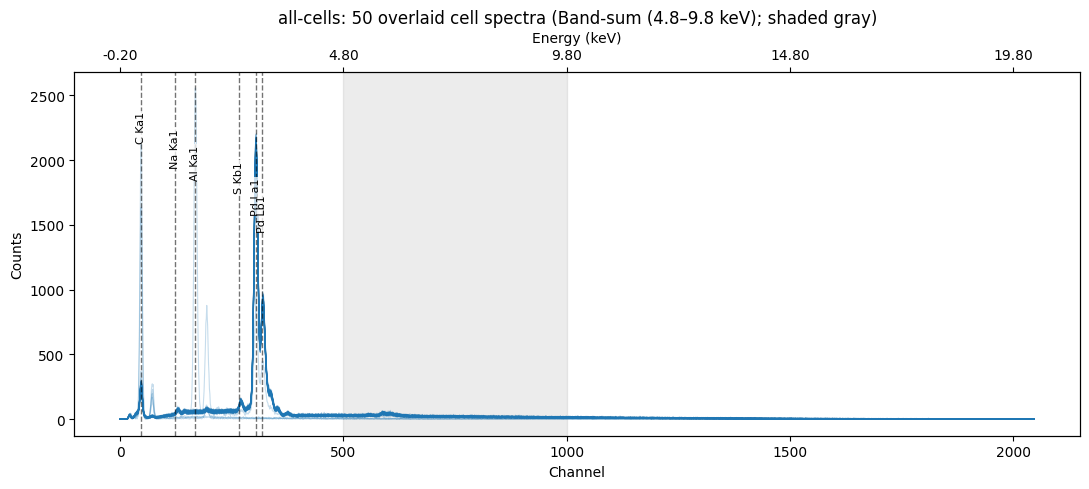

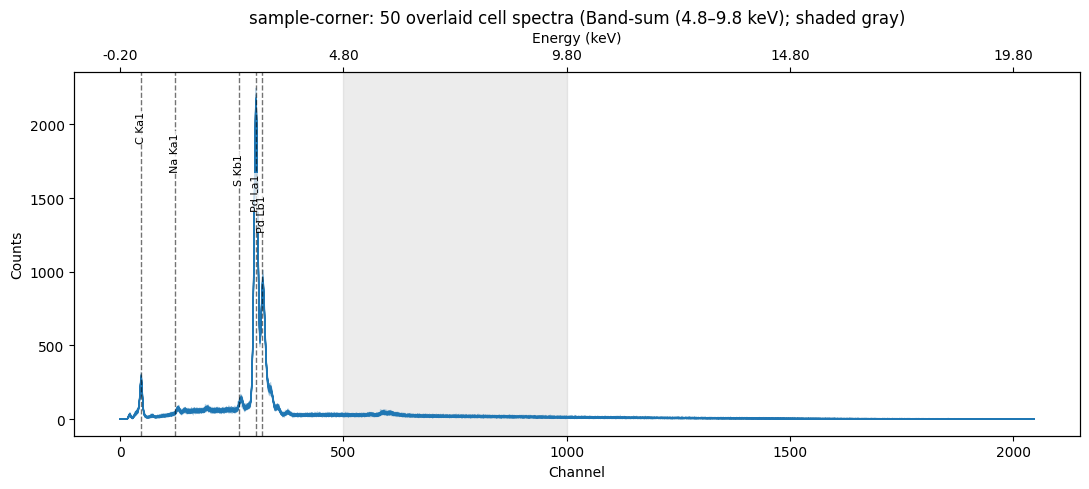

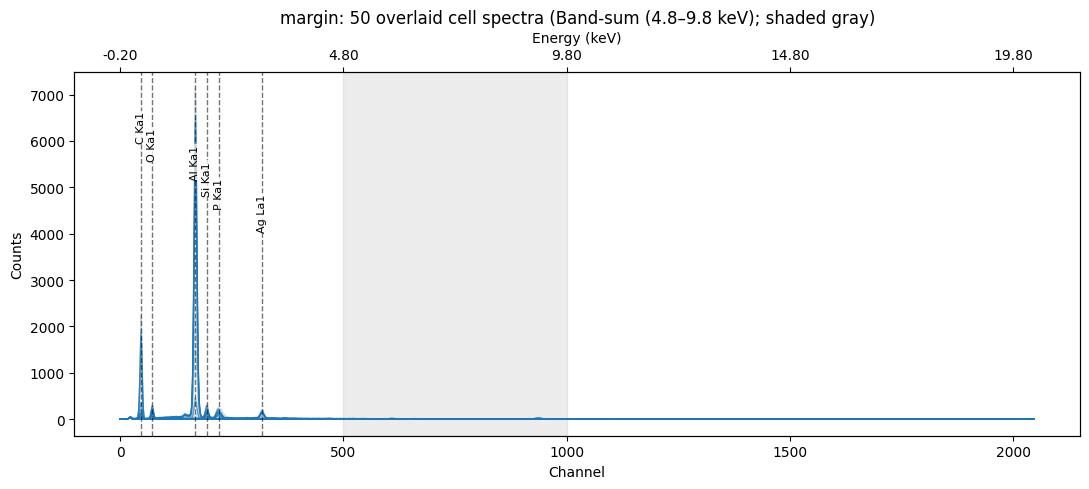

In [13]:
# Overlay up to 50 individual cell spectra per region, with element annotations and the selected band shaded in gray.

N_OVERLAY_SPECTRA = 50

plot_overlaid_cell_spectra(
    aggregate_results=aggregate_results,
    peak_summary=peak_summary,
    band_start=BAND_START,
    band_end=BAND_END,
    band_mode=BAND_MODE,
    cal=cal,
    show_energy_top_axis=SHOW_ENERGY_TOP_AXIS,
    n_overlay_spectra=N_OVERLAY_SPECTRA,
    peak_top_n_labels=PEAK_TOP_N_LABELS,
    peak_fwhm_mn_ev=PEAK_FWHM_MN_EV,
    show_peak_crosses=False,
    show_element_lines=True,
    band_color="gray",
    band_alpha=0.15,
)

In [14]:
# Resolve the requested band to channel indices and compute per-cell band sums.

band_start_ch, band_end_ch = resolve_band_to_channels(
    BAND_START,
    BAND_END,
    band_mode=BAND_MODE,
    cal=cal,
)

print(f"Resolved analysis band: {band_start_ch}–{band_end_ch} channels")
if str(BAND_MODE).lower() == "kev":
    print(f"Requested in energy units: {BAND_START}–{BAND_END} keV")

if cal is not None:
    band_lo_keV = channel_to_keV(band_start_ch, cal)
    band_hi_keV = channel_to_keV(band_end_ch, cal)
    source_text = "config.txt" if cal.get("from_config") else "defaults"
    print(f"Resolved energy span: {band_lo_keV:.3f}–{band_hi_keV:.3f} keV ({source_text})")

for name, res in aggregate_results.items():
    res["df"] = res["df"].copy()
    res["df"]["band_value"] = res["df"]["spectrum"].apply(lambda s: band_sum(s, band_start_ch, band_end_ch))

Resolved analysis band: 500–1000 channels
Requested in energy units: 4.8–9.8 keV
Resolved energy span: 4.802–9.801 keV (config.txt)


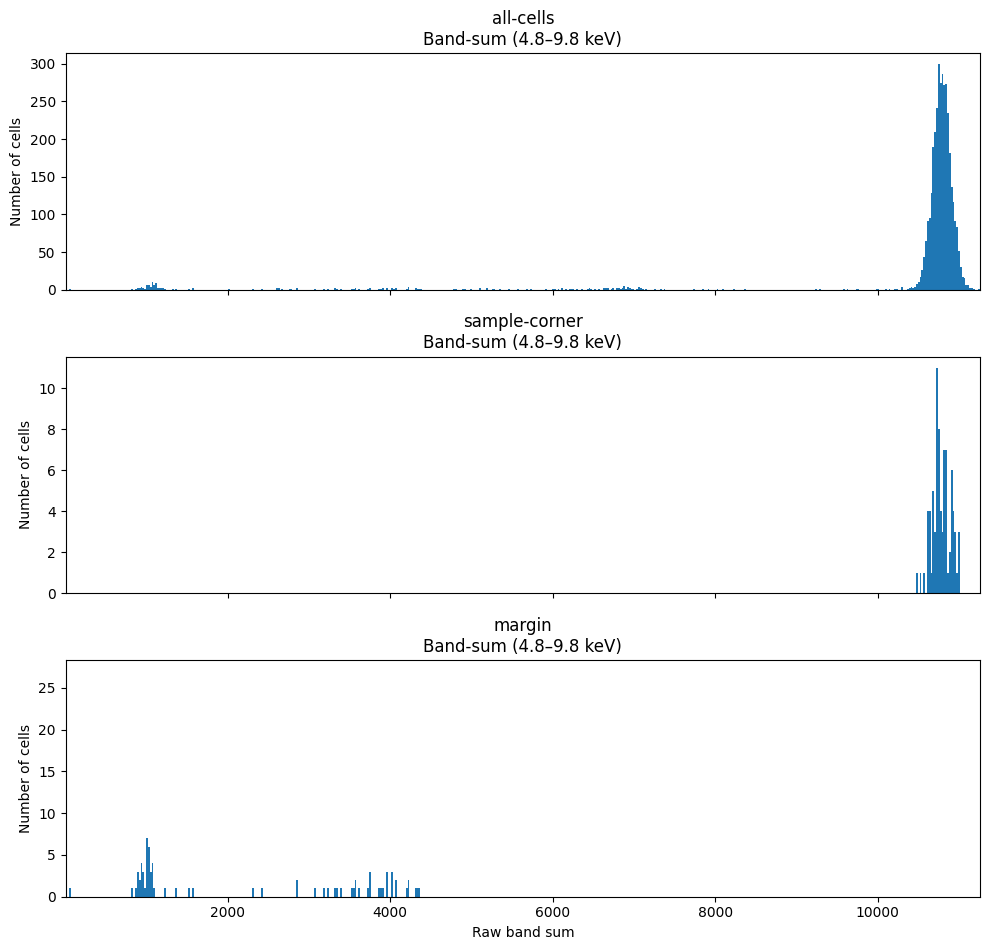

In [15]:
# Build vertically stacked histograms with shared bins and a shared global x-axis range.

# Shared bins across all aggregates
all_band_vals = np.concatenate([
    res["df"]["band_value"].dropna().to_numpy(dtype=float)
    for res in aggregate_results.values()
    if len(res["df"]) > 0
])

global_min = float(np.min(all_band_vals))
global_max = float(np.max(all_band_vals))

if global_max > global_min:
    shared_bins = np.linspace(global_min, global_max, HIST_BINS + 1)
else:
    shared_bins = np.array([global_min - 0.5, global_max + 0.5])

n = len(aggregate_results)

fig, axes = plt.subplots(
    n, 1,
    figsize=(10, 3.2 * n),
    sharex=True,
    squeeze=False
)
axes = axes[:, 0]

for i, (ax, (name, res)) in enumerate(zip(axes, aggregate_results.items())):
    vals = res["df"]["band_value"].dropna().to_numpy(dtype=float)
    ax.hist(vals, bins=shared_bins)

    ax.set_xlim(global_min, global_max)
    ax.set_ylabel("Number of cells")
    ax.set_title(f"{name}\n{band_label_text(BAND_START, BAND_END, BAND_MODE)}")

    if i < n - 1:
        ax.tick_params(axis="x", labelbottom=False)

axes[-1].set_xlabel("Raw band sum")

plt.tight_layout()
plt.show()

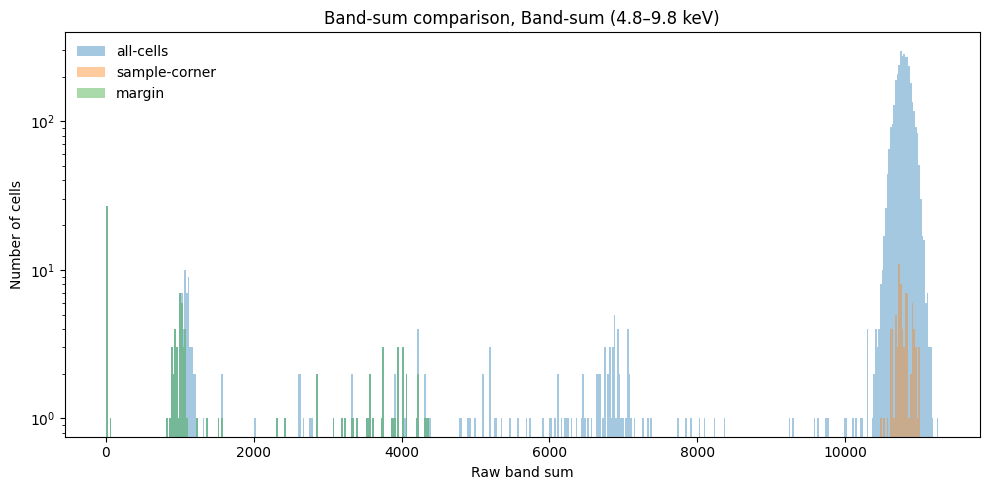

In [16]:
# Overlay all band-sum histograms on one log-scale plot for direct comparison.

plt.figure(figsize=(10, 5))

for name, res in aggregate_results.items():
    vals = res["df"]["band_value"].dropna().to_numpy(dtype=float)
    plt.hist(vals, bins=shared_bins, alpha=0.40, label=name)

plt.yscale("log")
plt.xlabel("Raw band sum")
plt.ylabel("Number of cells")
plt.title(f"Band-sum comparison, {band_label_text(BAND_START, BAND_END, BAND_MODE)}")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [17]:
# Summarize the band-sum distributions and propose value ranges for overlays.

stats_rows = []

for name, res in aggregate_results.items():
    stats = summarize_band_values(res["df"]["band_value"])
    stats["roi_name"] = name
    stats_rows.append(stats)

stats_df = pd.DataFrame(stats_rows).set_index("roi_name")

range_suggestions_df = pd.DataFrame({
    "global_min": int(round(global_min)),
    "global_max": int(round(global_max)),
    "vmin_mild": stats_df["p05"].round().astype(int),
    "vmax_mild": stats_df["p95"].round().astype(int),
    "vmin_strong": stats_df["p10"].round().astype(int),
    "vmax_strong": stats_df["p90"].round().astype(int),
    "threshold_candidate": stats_df["p10"].round().astype(int),
}, index=stats_df.index)

display(stats_df.round(3))
display(range_suggestions_df)

,n,min,p01,p05,p10,p25,p50,p75,p90,p95,p99,max,mean,std
roi_name,,,,,,,,,,,,,,
all-cells,3780,4.0,944.58,6629.85,10587.9,10699.00,10782.0,10859.00,10932.0,10977.00,11057.21,11262.0,10321.217,1915.600
sample-corner,80,10489.0,10522.97,10616.95,10640.7,10725.25,10771.5,10857.25,10940.3,10967.20,10998.26,11003.0,10786.525,112.509
margin,104,4.0,6.00,9.00,11.0,17.00,1029.0,3432.50,4010.6,4187.05,4343.89,4367.0,1672.760,1543.783


,global_min,global_max,vmin_mild,vmax_mild,vmin_strong,vmax_strong,threshold_candidate
roi_name,,,,,,,
all-cells,4,11262,6630,10977,10588,10932,10588
sample-corner,4,11262,10617,10967,10641,10940,10641
margin,4,11262,9,4187,11,4011,11


*Step 4: Optionally create or delete overlay heatmap files in the Surface Viewer.*

## 4. Optional: create overlay heatmap files


In [18]:
# Choose the display range to apply when creating the overlay heatmap.

# Pick one of the suggested ranges from range_suggestions_df above, then edit if desired.
VMIN = 0
VMAX = 11262

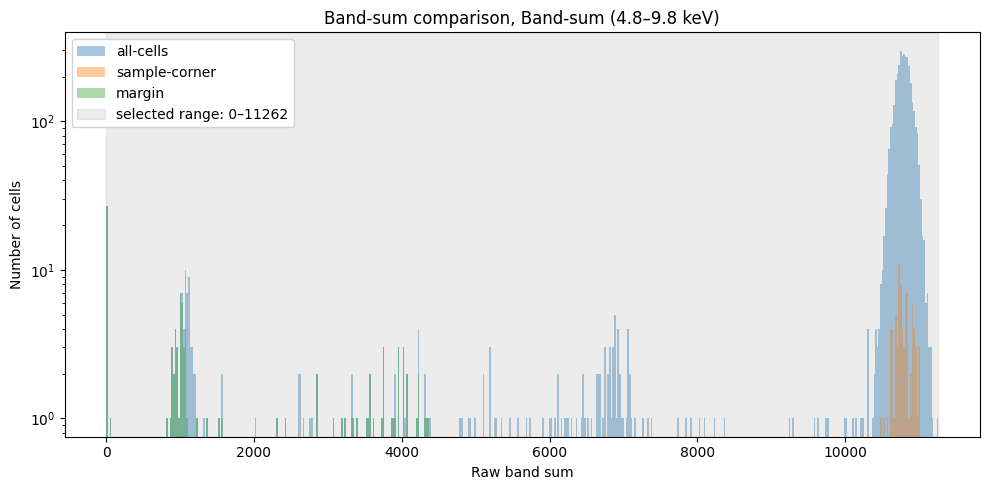

In [19]:
# Preview the chosen overlay range on the combined log-scale band-sum histogram.

plt.figure(figsize=(10, 5))

for name, res in aggregate_results.items():
    vals = res["df"]["band_value"].dropna().to_numpy(dtype=float)
    plt.hist(vals, bins=shared_bins, alpha=0.40, label=name)

plt.axvspan(VMIN, VMAX, color="gray", alpha=0.15, label=f"selected range: {VMIN}–{VMAX}")

plt.yscale("log")
plt.xlabel("Raw band sum")
plt.ylabel("Number of cells")
plt.title(f"Band-sum comparison, {band_label_text(BAND_START, BAND_END, BAND_MODE)}")
plt.legend(frameon=True, facecolor="white", framealpha=1.0, edgecolor="lightgray", loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
# Authenticate to the overlay API and extract dataset metadata from the ROI URL.

auth = get_api_auth()

dataset = parse_qs(urlparse(ROI_API_URLS[0]).query)["dataset"][0]
input_folder = "aggregated-spectra"

print("Dataset:", dataset)
print("Input folder:", input_folder)
print(f"Using resolved band: {band_start_ch}–{band_end_ch} channels")

API username: ··········
API password: ··········
Dataset: JPB1_Pd-TF-11_EDS_post (20250825_sample 9 (eds))
Input folder: aggregated-spectra
Using resolved band: 500–1000 channels


In [21]:
# Create the overlay heatmap and print both the overlay URL and the sample viewer link.

resp_create = create_overlay(
    auth=auth,
    dataset=dataset,
    input_folder=input_folder,
    band_start=band_start_ch,
    band_end=band_end_ch,
    vmin=VMIN,
    vmax=VMAX,
)

overlay_file = resp_create["output_file"]
print("Created:", overlay_file)
print("URL:", resp_create["output_url"])

sample_viewer_url = f"https://nucleonics.mit.edu/surface-viewer/?dataset={quote_plus(dataset)}"
resp_create["sample_viewer_url"] = sample_viewer_url
print("Sample viewer:", sample_viewer_url)


Status: 200
{'ok': True, 'action': 'create', 'dataset': 'JPB1_Pd-TF-11_EDS_post (20250825_sample 9 (eds))', 'input_folder': 'aggregated-spectra', 'output_file': 'overlays/heatmap_ch500-1000_rng0-11262.json', 'output_url': 'https://nucleonics.mit.edu/surface-viewer/data/JPB1_Pd-TF-11_EDS_post%20%2820250825_sample%209%20%28eds%29%29/overlays/heatmap_ch500-1000_rng0-11262.json', 'output_exists': True, 'dry_run': False, 'stdout': 'Wrote 3780 rectangles → /home/lenr/proxy-server/surface-viewer/data/JPB1_Pd-TF-11_EDS_post (20250825_sample 9 (eds))/overlays/heatmap_ch500-1000_rng0-11262.json\n', 'stderr': ''}
Created: overlays/heatmap_ch500-1000_rng0-11262.json
URL: https://nucleonics.mit.edu/surface-viewer/data/JPB1_Pd-TF-11_EDS_post%20%2820250825_sample%209%20%28eds%29%29/overlays/heatmap_ch500-1000_rng0-11262.json
Sample viewer: https://nucleonics.mit.edu/surface-viewer/?dataset=JPB1_Pd-TF-11_EDS_post+%2820250825_sample+9+%28eds%29%29


In [22]:
# Show the current overlay filename for quick reuse or copy/paste.

overlay_file

'overlays/heatmap_ch500-1000_rng0-11262.json'

In [23]:
# Specify an overlay filename if you want to delete an existing overlay.

overlay_file_to_be_deleted = "overlays/heatmap_ch500-1000_rng9000-12000.json"  # replace with the file you want to delete

In [24]:
# # Delete the selected overlay heatmap file from the server.

# resp_delete = delete_overlay(
#     auth=auth,
#     dataset=dataset,
#     overlay_file=overlay_file_to_be_deleted,
# )